### Clean HRRR-AK NetCDF Files

Notebook contents 
* We processed with grib files from folders in `1_process_hrrrak_grib_files` and now we need to do some cleaning and save cleaned netcdfs
* When we created the netcdfs, we did not fix the dimensions and crs, so I am doing that here then resaving the file

created by Cassie Lumbrazo\
last updated: April 2025, updated Jan 2026\
run location: UAS linux\
python environment: **rasterio**

In [14]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [3]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

In [4]:
# load the netcdf 
# ds = xr.open_dataset('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2024.nc') # these files don't exist anymore, they were before specifying forecast hours
# ds = xr.open_dataset('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2025.nc') 

# load the netcdf 
hrrr_input_file = ('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1.nc') # raw hrrr data has dimension stuff going on...

ds = xr.open_dataset(hrrr_input_file)
ds

<xarray.Dataset> Size: 289MB
Dimensions:                  (time: 3311, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 26kB ...
    valid_time               (time) datetime64[ns] 26kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables: (12/52)
    pt                       (time, y, x) float32 6MB ...
    temp                     (time, y, x) float32 6MB ...
    d2m                      (time, y, x) float32 6MB ...
    sh2                      (time, y, x) float32 6MB ...
    rh                       (time, y, x) float32 6MB ...
    u10                      (time, y, x) float32 6MB ...
    ...                       ...
    lai                      (time, y, x) float32 6MB ...
    vgtyp                    (time, y, x) float32 6MB ...
    cloud_total              (time, y, x) float32 6MB ...
    cloud_high               (time, y, x) float32 6MB ...
    cloud_low                (time, y, x) float32 6MB ...
    wind                     (time, y, x) float32 6MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

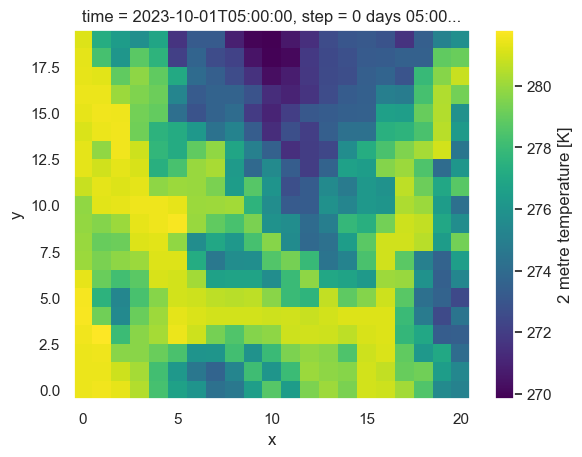

In [5]:
ds.temp[0].plot()

So, we can see that the x an y are from 0 to 20, so just distance without a crs, let's check it 

In [6]:
print(ds.rio.crs)

None


So there is no assigned crs, let's start by assigning one

In [7]:
ds.rio.write_crs("EPSG:4326", inplace=True)

<xarray.Dataset> Size: 289MB
Dimensions:                  (time: 3311, y: 20, x: 21)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 26kB ...
    valid_time               (time) datetime64[ns] 26kB ...
    latitude                 (y, x) float64 3kB ...
    longitude                (y, x) float64 3kB ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Dimensions without coordinates: y, x
Data variables: (12/52)
    pt                       (time, y, x) float32 6MB ...
    temp                     (time, y, x) float32 6MB ...
    d2m                      (time, y, x) float32 6MB ...
    sh2                      (time, y, x) float32 6MB ...
    rh                       (time, y, x) float32 6MB ...
    u10                      (time, y, x) float32 6MB ...
    ...                       ...
    lai                      (time, y, x) float32 6MB ...
    vgtyp                    (time, y, x) float32 6MB ...
    cloud_total              (time, y, x) float32 6MB ...
    cloud_high               (time, y, x) float32 6MB ...
    cloud_low                (time, y, x) float32 6MB ...
    wind                     (time, y, x) float32 6MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

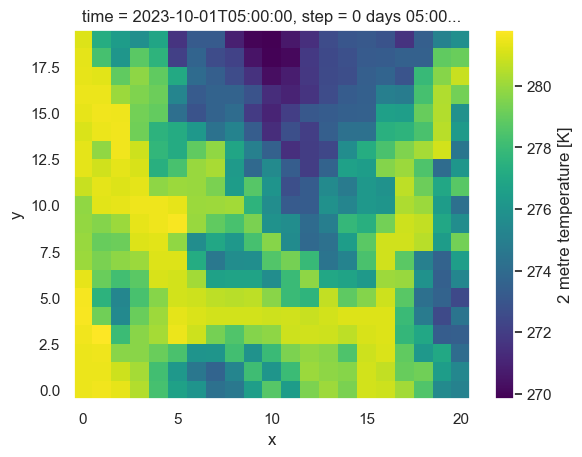

In [8]:
ds.temp[0].plot()

So now we need to fix up the dimensions and reproject to utm

In [9]:
# Step 1: Rename dimensions if needed and set spatial dims
ds = ds.rename({'longitude': 'x', 'latitude': 'y'})
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Step 2: Extract 1D x and y coordinates from the 2D grid
# Grab 1D x and y
x_1d = ds['x'].isel(y=0)  # same x values across rows
y_1d = ds['y'].isel(x=0)  # same y values down columns

# Assign 1D coords to the dataset
ds = ds.assign_coords(x=x_1d, y=y_1d)

# Step 3: Drop the 2D coords from the coordinate system
ds = ds.drop_vars(['x', 'y'])  # remove old 2D variables
ds = ds.set_coords([])         # ensure no unexpected spatial coords

# Step 4: Reassign the cleaned 1D coords
ds = ds.assign_coords({'x': x_1d, 'y': y_1d})

# Step 5: Now, reproject to UTM
# Now reproject to UTM
ds_utm = ds.rio.reproject("EPSG:32608")

In [10]:
print(ds_utm.rio.crs)

EPSG:32608


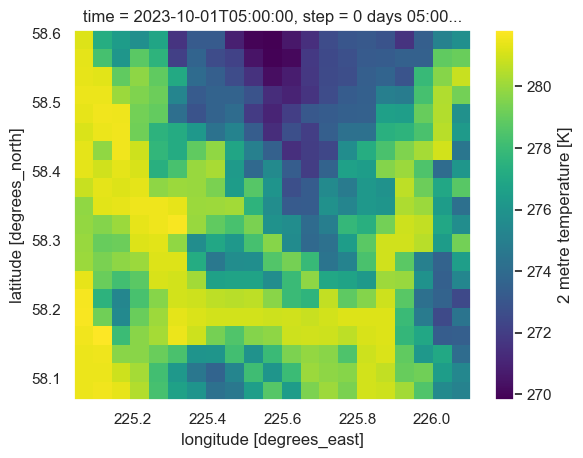

In [11]:
ds.temp[0].plot()

So that looks great, now the crs is actually set, reporjected to utm, and the data can be easily used. 

## So, we are in UTM Zone 8N (EPSG:32608)
To get the Powder Patch, or any other point location, 

we need to project the lat/lon for those locations (which are in WGS84) into EPSG:3268, and then plot them together 

In [15]:
# Site coordinates (lat/lon, WGS84)
lat_faa, lon_faa = 58.26139, -134.51056
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700

# Create GeoDataFrame for the two sites
gdf_sites = gpd.GeoDataFrame({
    "site": ["FAA", "Powder Patch"],
    "geometry": [Point(lon_faa, lat_faa), Point(lon_powderpatch, lat_powderpatch)]
}, crs="EPSG:4326")

# Convert sites to same projection as dataset (UTM Zone 8N)
gdf_sites_proj = gdf_sites.to_crs("EPSG:32608")

# Extract projected coordinates
x_faa, y_faa = gdf_sites_proj.geometry[0].x, gdf_sites_proj.geometry[0].y
x_pp, y_pp = gdf_sites_proj.geometry[1].x, gdf_sites_proj.geometry[1].y

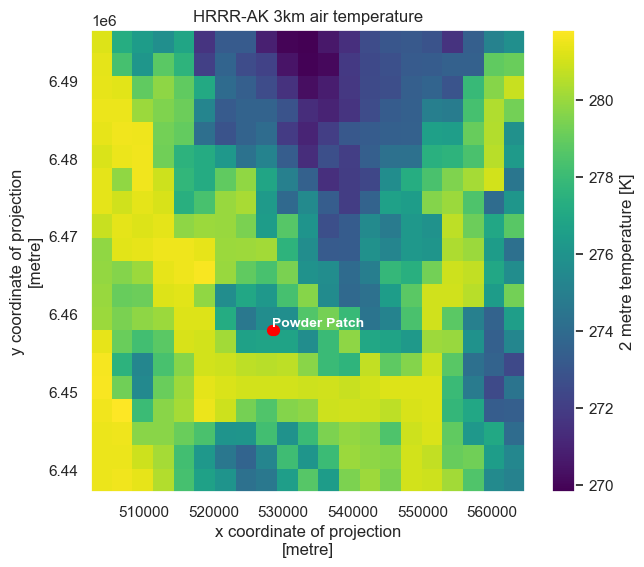

In [18]:
# Choose one time step (e.g., first one)
t0 = ds_utm.time[0]

# Select wind speed variable for that time
da_plot = ds_utm["temp"].sel(time=t0)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
da_plot.plot(ax=ax, cmap="viridis")

# Overlay points
ax.scatter([x_faa, x_pp], [y_faa, y_pp], color="red", s=50, zorder=3)
# ax.text(x_faa, y_faa, "FAA", color="white", fontsize=10, weight="bold", ha="left", va="bottom")
ax.text(x_pp, y_pp, "Powder Patch", color="white", fontsize=10, weight="bold", ha="left", va="bottom")

# Zoom in around the two sites
# buffer = 100  # meters (adjust for resolution)
# buffer = 1000  # would be 1km on each side
# ax.set_xlim(min(x_faa, x_pp) - buffer, max(x_faa, x_pp) + buffer)
# ax.set_ylim(min(y_faa, y_pp) - buffer, max(y_faa, y_pp) + buffer)

# ax.set_title(f"Wind Speed at {str(t0.values)[:16]}")
ax.set_title('HRRR-AK 3km air temperature')
plt.show()

In [25]:
# create a new variable in the dataset for temperature in Celsius
ds_utm['temp_c'] = ds_utm['temp'] - 273.15

Now we plotted them, but let's select and save the gridcell that the point is within

In [26]:
# ds_faa = ds_utm.sel(y=lat_faa, x=lon_faa, method='nearest') # this works, but we need to be careful that the lat/lon are in UTM (meters)

# Site lat/lon
lat_faa, lon_faa = 58.26139, -134.51056
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700

# Convert to UTM Zone 8N
gdf_sites = gpd.GeoDataFrame({
    "site": ["FAA", "Powder Patch"],
    "geometry": [Point(lon_faa, lat_faa), Point(lon_powderpatch, lat_powderpatch)]
}, crs="EPSG:4326").to_crs("EPSG:32608")

x_faa, y_faa = gdf_sites.geometry[0].x, gdf_sites.geometry[0].y
x_pp, y_pp = gdf_sites.geometry[1].x, gdf_sites.geometry[1].y

# Select nearest grid cells
ds_faa = ds_utm.sel(x=x_faa, y=y_faa, method="nearest")
ds_pp = ds_utm.sel(x=x_pp, y=y_pp, method="nearest")

print(ds_faa)
print(ds_pp)

<xarray.Dataset> Size: 781kB
Dimensions:                  (time: 3311)
Coordinates:
    x                        float64 8B 5.276e+05
    y                        float64 8B 6.456e+06
    boundaryLayerCloudLayer  float64 8B 0.0
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    step                     (time) timedelta64[ns] 26kB 05:00:00 ... 07:00:00
    valid_time               (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    spatial_ref              int64 8B 0
Data variables: (12/53)
    pt                       (time) float32 13kB 280.0 279.9 ... 278.5 278.4
    temp                     (time) float32 13kB 276.8 276.7 ... 276.0 275.9
    d2m                      (time) float32 13kB 276.8 276.7 ... 256.6 258.7
    sh2                      (time) float32 13kB 0.00514 0.00511 ... 0.001291
    rh                       (time) float32 13kB 100.0 100.0 100.0 ... 18.3 22.2
    u10                      (time) float32 13kB -6.223 -6.486 ... -2.625 -3.

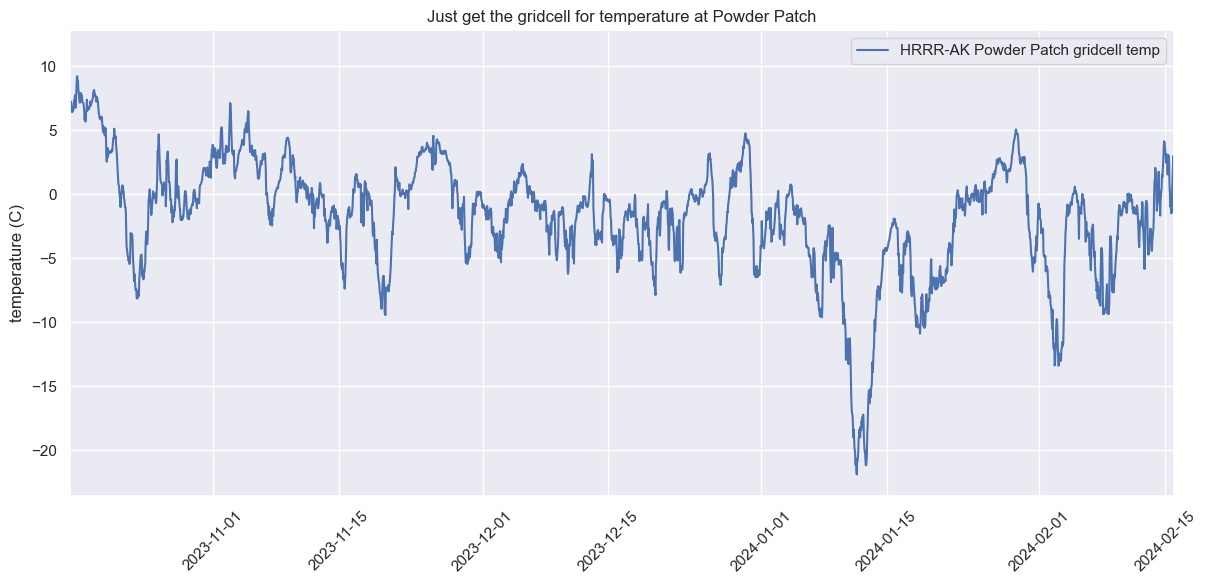

In [30]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_pp['time'].values, ds_pp['temp_c'].values, color='b', label='HRRR-AK Powder Patch gridcell temp')
# plt.plot(ds_faa['time'].values, ds_faa['temp_c'].values, color='r')

plt.title('Just get the gridcell for temperature at Powder Patch')
# plt.xlabel('Time')
plt.ylabel('temperature (C)')
plt.legend()
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()

# zoom into a few days only on the xaxis
plt.xlim(pd.to_datetime('2023-10-16'), pd.to_datetime('2024-02-16'))
# plt.xlim(pd.to_datetime('2024-02-10'), pd.to_datetime('2024-02-16'))

plt.show()

## Save cleaned up NetCDF 

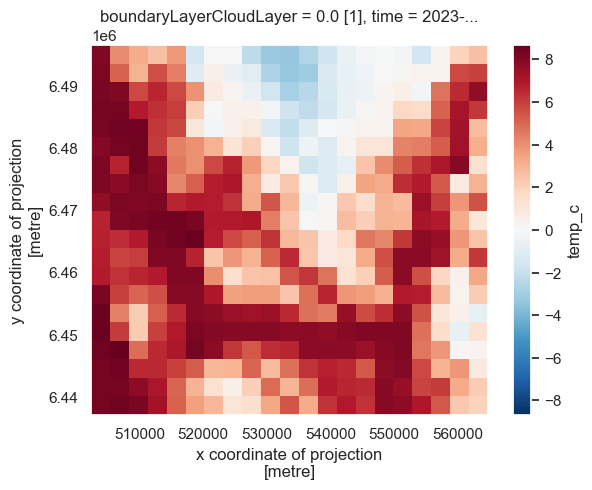

In [31]:
# plot one temperature just to check 
ds_utm.temp_c[0].plot()

Good, that's the right file. Now save this, and then open this netcdf next time we need to work with it. 

In [32]:
# save the cleaned up netcdf with crs and dimensions fixed for future use, 
# hrrr_input_file = ('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1.nc') # raw hrrr data has dimension stuff going on...

output_file = '/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1_utm.nc'
ds_utm.to_netcdf(output_file)